<a href="https://colab.research.google.com/github/Dipanjan-Chaudhuri/Exact-Diagonalization-on-1D-spin-chain/blob/main/ED_of_1D_Quantum_Spin_Chains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objective:

Build an ED solver in Python that uses bitwise state representation, symmetry sector decomposition, and sparse matrix methods to calculate ground state properties and entanglement entropy.

We will be using the Heisenberg XXZ 1D spin-1/2 chain,

$$ H = \sum_{i=1}^{N} \Big[\frac{J}{2}(S^{+}_{i}S^{-}_{i+1} + S^{-}_{i}S^{+}_{i+1}) + \Delta \ (S^{z}_{i}S^{z}_{i+1})\Big] $$

Looking at this Hamiltonian, it is clear that the total magnetization in the $z$-direction $m^z = \sum_{i=1}^{N} S^{z}_{i}$ remains conserved because, $$[H,m^z] = 0.$$

Due to this, the Hamiltonian is fractured into a block diagonal form, where each block corresponds to a specific symmetry sector (specific value of $m^z$). This fact can be used to solve for the ground state of the Hamiltonian be exactly diagonalizing the Hamiltonian block that corresponds to the ground state configuration of spins.  

This is computationally much more feasible as instead of a matrix that is $2^{N} \times 2^{N}$ we have to diagonalize a much smaller block corresponding to the symmetry sector we are looking for.

This is the essential idea behind **Exact Diagonalization** or **ED**.

In [1]:
# Libraries
# ---------
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from scipy.linalg import svd
import matplotlib.pyplot as plt

In [2]:
'''
Generating the basis on which we would construct our Hamiltonian.
This is not the true hamiltonian, but the block corrosponding to a specific number of up-spins N_up.
That is, we are already restricting ourselves to a symmetry block corresponding to some m^z.
'''

def generate_basis(N,N_up):
  basis = []
  for state in range(2**N):
    if bin(state).count('1') == N_up:
      # Counting the number of up spins in the state, in bitwise representation.
      basis.append(state)

  state_to_index = {state : i for i,state in enumerate(basis)}
  # The above dictionary maps the states in our chosen symmetry block to indices according to their position in the list of basis. This helps us find the specific state in the basis from it's index later when the Hamiltonian is flipping bits of the basis states.

  return basis, state_to_index

In [3]:
def build_hamiltonian_nn(N, basis, state_to_index, J = 1.0 , Delta = 1.0):
  dim = len(basis)
  H = sp.lil_matrix((dim,dim), dtype = np.float64)
  # LIL matrix allows for computationally cheap addition of elements in a sparse matrix. Element is appended, instead of the matrix being reconstructed everytime.

  for i,state in enumerate(basis):
    for site in range(N):

      nn_site = (site + 1) % N    # Periodic Boundary conditions for nearest-neighbour sites

      bit1 = (state >> site) & 1
      bit2 = (state >> nn_site) & 1

      if bit1 == bit2 : # Spins are aligned
        H[i,i] += Delta * 0.25

      else :   # Spin anti-aligned
        H[i,i] -= Delta * 0.25

        flipped_state = state^(1 << site | 1 << nn_site)    # Check multi-line comment below ⬇️
        j = state_to_index[flipped_state]
        H[i,j] += J * 0.5

  return H.tocsr()


  '''
  The factor (1 << site | 1 << next_site) gives us the positions of the two anti-aligned spins,
  the XOR operator (^) does the flipping part by comparing the spin state with the mask containing the positions of the anti-aligned spins,
  so that they can be flipped without affecting the other spins at other lattice sites.
  '''

In [4]:
def build_hamiltonian_nnn(N, basis, state_to_index,
                          J1 = 1.0 , Delta1 = 1.0, J2 = 1.0, Delta2 = 1.0):
  dim = len(basis)
  H = sp.lil_matrix((dim,dim), dtype = np.float64)
  # LIL matrix allows for computationally cheap addition of elements in a sparse matrix. Element is appended, instead of the matrix being reconstructed everytime.

  for i,state in enumerate(basis):
    for site in range(N):

      nn_site = (site + 1) % N    # Periodic Boundary conditions for nearest-neighbour sites
      nnn_site = (site + 2) % N   # Periodic Boundary conditions for next nearest-neighbour sites

      bit1 = (state >> site) & 1
      bit2 = (state >> nn_site) & 1
      bit3 = (state >> nnn_site) & 1

      # Nearest-neighbour Block

      if bit1 == bit2 : # Spins are aligned
        H[i,i] += Delta1 * 0.25

      else :   # Spin anti-aligned
        H[i,i] -= Delta1 * 0.25

        flipped_state = state^(1 << site | 1 << nn_site)
        H[i,j] += J1 * 0.5

      # Next nearest-neighbour Block
      if bit1 == bit3 :
        H[i,i] += Delta2 * 0.25

      else :
        H[i,i] -= Delta2 * 0.25

        flipped_state = state^(1 << site | 1 << nnn_site)
        j = state_to_index[flipped_state]
        H[i,j] += J2 * 0.5

  return H.tocsr()

In [18]:
def main():

  N = 14
  N_up = N//2     # m^z = 0
  J = 1.0         # Exchange coupling
  Delta = 1.0     # Anisotropy

  # Generating the Basis

  basis,state_to_index = generate_basis(N,N_up)
  dim = len(basis)

  print(f"Restricted Hilbert Space dimension = {dim}")

  # Building the Hamiltonian

  H = build_hamiltonian_nn(N,basis,state_to_index,J,Delta)

  # Exact Diagonalization (Lanczos)
  # k = 1 gives the ground state
  # which = 'SA' searches for Smallest Algebraic eigenvalues
  eigenenergies, eigenvectors = eigsh(H, k = 1, which = 'SA')

  E_0 = eigenenergies[0]
  psi_0 = eigenvectors[:,0]

  entropy = half_chain_entanglement_entropy(N, psi_0, basis)
  print(f"Ground State Energy = {E_0}")
  print(f"Half-chain Entanglement Entropy = {entropy}")

In [14]:
from scipy.linalg import svd

def half_chain_entanglement_entropy(N, psi_0, basis):

  # To get the half chain entanglement entropy, we need to map psi_0 back into the full Hilbert space

  full_psi = np.zeros(2**N, dtype=np.float64)

  for i, state in enumerate(basis):
      full_psi[state] = psi_0[i]

  N_A = N//2        # Left sites
  N_B = N - N_A     # Right sites

  full_psi = full_psi.reshape((2**N_A,2**N_B))

  # Computing SVD
  S = svd(full_psi, compute_uv=False)

  eigenvalues = S**2

  eigenvalues = eigenvalues[eigenvalues > 1e-12]
  # Avoiding ln(0) errors
  entropy = -np.sum(eigenvalues * np.log(eigenvalues))
  # Entanglement entropy

  return entropy

In [19]:
if __name__ == "__main__":
  main()

Restricted Hilbert Space dimension = 3432
Ground State Energy = -6.263549533547033
Half-chain Entanglement Entropy = 1.2352922409192213


## Quantum Phase Transition:

Here we look at the variation of entanglement entropy $(S_{vN})$ with anisotropy parameter $(Δ)$. We expect to see a drop in the entanglement entropy as the anisotrpy parameter increases and crosses the isotropic point $(Δ > 1)$. This corresponds to a phase transition from a highly correlated entangled system to a purely ordered Neel Phase (perfect antiferromagnetic product state, no entanglement).

Scanning phase transition for N=16...


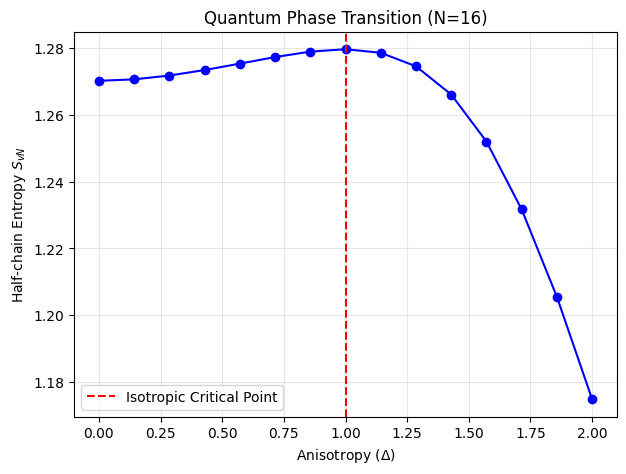

In [20]:
N_scan = 16
N_up_scan = N_scan // 2
J_scan = 1.0
deltas = np.linspace(0.0, 2.0, 15)
entropies = []

# Basis only needs to be generated once for a fixed N
basis_scan, state_to_index_scan = generate_basis(N_scan, N_up_scan)

print(f"Scanning phase transition for N={N_scan}...")
for d in deltas:
    H_scan = build_hamiltonian_nn(N_scan, basis_scan, state_to_index_scan, J_scan, d)
    eigenenergies_scan, eigenvectors_scan = eigsh(H_scan, k=1, which='SA')
    psi_0_scan = eigenvectors_scan[:, 0]

    entropy = half_chain_entanglement_entropy(N_scan, psi_0_scan, basis_scan)
    entropies.append(entropy)

plt.figure(figsize=(7, 5))
plt.plot(deltas, entropies, marker='o', color='b')
plt.axvline(1.0, color='r', linestyle='--', label='Isotropic Critical Point')
plt.xlabel(rf'Anisotropy ($\Delta$)')
plt.ylabel(r'Half-chain Entropy $S_{vN}$')
plt.title(f'Quantum Phase Transition (N={N_scan})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('phase_transition.png', dpi=300, bbox_inches='tight')
plt.show()

## Finite-Size Scaling ($E/N$ vs $1/N$)


Here we try to expand the calculation of the energy per site upto the thermodynamic limit $(N \to ∞)$. This has been done by plotting the variation of the ground state energy of each site with the inverse of the system size. We evaluate $E/N$ for certain fixed system sizes starting from $N = 8$ reaching upto $N = 18$, beyond which we encounter a memory threshold. Hence, thereafter we have to resort to extrapolation via curve fitting technques. We have assumed a polynomial fitting function.

According to literature, this polynomial extrapolation must eventually approach the Bethe Ansatz at the thermodynamic limit. Which is what we are trying to verify here.

Performing finite-size scaling...


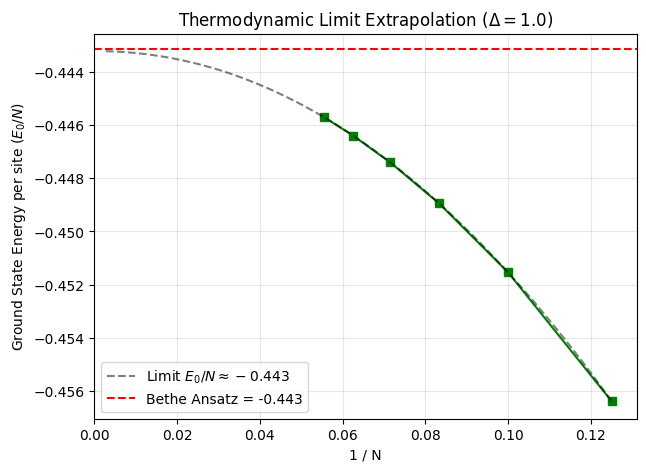

In [21]:
sizes = [8, 10, 12, 14, 16, 18]
energies_per_site = []
inv_N = [1/n for n in sizes]
J_scale = 1.0
Delta_scale = 1.0
bethe_ansatz = 0.25 - np.log(2)

print("Performing finite-size scaling...")
for n in sizes:
    n_up = n // 2
    basis_scale, state_to_index_scale = generate_basis(n, n_up)
    H_scale = build_hamiltonian_nn(n, basis_scale, state_to_index_scale, J_scale, Delta_scale)

    eigenenergies_scale, _ = eigsh(H_scale, k=1, which='SA')
    energies_per_site.append(eigenenergies_scale[0] / n)

plt.figure(figsize=(7, 5))
plt.plot(inv_N, energies_per_site, marker='s', color='g')

from scipy.optimize import curve_fit

# Defining the polynomial function to fit
def fitting_func(x, a, b, c):
    return a*x**b + c

x_data = np.array(inv_N)
y_data = np.array(energies_per_site)

# Perform the curve fit
popt, pcov = curve_fit(fitting_func, x_data, y_data)
a_fit, b_fit, c_fit = popt

x_fit = np.linspace(min(x_data) * 0.05, max(x_data), 100)
y_fit = fitting_func(x_fit, a_fit, b_fit, c_fit)


plt.plot(x_fit, y_fit, '--k', alpha=0.5, label=rf'Limit $ E_0/N \approx {c_fit:.3f}$')

plt.axhline(y = bethe_ansatz , color = "r", linestyle = "--", label = rf"Bethe Ansatz = {bethe_ansatz:.3f}")
plt.legend()
plt.xlabel('1 / N')
plt.ylabel(r'Ground State Energy per site ($E_0 / N$)')
plt.title(r'Thermodynamic Limit Extrapolation ($\Delta=1.0$)')
plt.xlim(left=0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('finite_scaling.png', dpi=300, bbox_inches='tight')
plt.show()

##Spin Gap : Gapped and Gapless Phases

In this section, we try to simulate properties of spin gaps in a quantum phase. Here, we can see that the spin chain system, initially gapless when the anisotropy is less than the isotropic critical point $(\Delta < 1)$, develops a gap in the regime where $\Delta > 1$.  Essentially, we get a critical to insulating (Neel) phase transition.

This energy is the required amount of energy to flip a spin which leads to $m^z = 1$ from $m^z = 0$ magnetization. At low anisotropies $(Δ < 1)$, a spin flip is not localized in the spin chain and is "dissipated" throughout the chain by the $S_{i}^-S_{i+1}^+$ operators, as they are dominant in that regime. This means no energy is required to flip a spin in this regime (**Gapless Phase**).  

When $Δ > 1$, the diagonal terms $S_{i}^zS_{i+1}^z$ are dominating, which generates strongly ordered Neel anti-ferromagnetic phase. So, a spin flip generates a defect in the lattice that remains localized due to the strong $Δ$. This requires energy, which is exactly what we are calculating in this section. Stronger anisotropy must therefore lead to greater $\Delta E$ values (**Gapped Phase**).

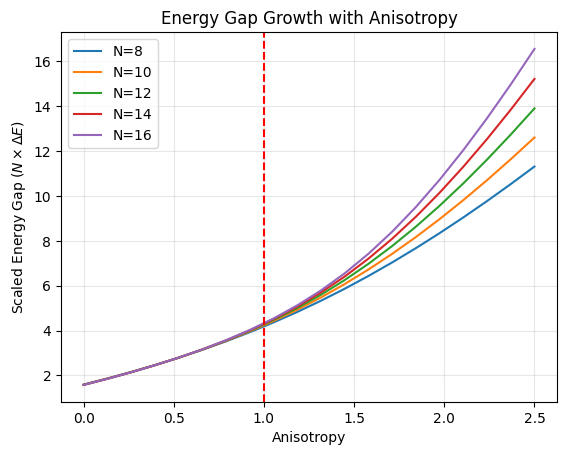

In [12]:
n = [8,10,12,14,16]
J = 1.0             # Exchange coupling
Deltas = np.linspace(0.0, 2.5, 20) # Anisotropy

for N in n:
    N_up_0 = N//2       # m^z = 0
    N_up_1 = N//2 + 1   # m^z = 1

    # Generating the Basis

    basis_0,state_to_index_0 = generate_basis(N,N_up_0)
    basis_1,state_to_index_1 = generate_basis(N,N_up_1)
    dim_0 = len(basis_0)
    dim_1 = len(basis_1)

    del_E = []

    for Delta in Deltas:
        # Building the Hamiltonians
        H_0 = build_hamiltonian_nn(N,basis_0,state_to_index_0,J,Delta) # For sector m^z = 0
        H_1 = build_hamiltonian_nn(N,basis_1,state_to_index_1,J,Delta) # For sector m^z = 1

        # Exact Diagonalization (Lanczos)
        eigenenergies_0, eigenvectors_0 = eigsh(H_0, k = 1, which = 'SA')
        eigenenergies_1, eigenvectors_1 = eigsh(H_1, k = 1, which = 'SA')

        del_E.append(eigenenergies_1[0]-eigenenergies_0[0])

    plt.plot(Deltas, np.array(del_E) * N, label = f"N={N}") # Scaling the Energy Gap to get a clear transition about isotropic critical point, in the thermodynamic limit.
    plt.xlabel("Anisotropy")
    plt.ylabel(r"Scaled Energy Gap $(N \times \Delta E)$")
    plt.title(r"Energy Gap Growth with Anisotropy")
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.axvline(x = 1.0, color = "r", linestyle = "--", label = "Isotropic Critical Point")
plt.savefig('scaled_spin_gap.png', dpi=300, bbox_inches='tight')

# Quantum Spin Liquid transition:
## Introducing Next-Nearest Neighbour interactions

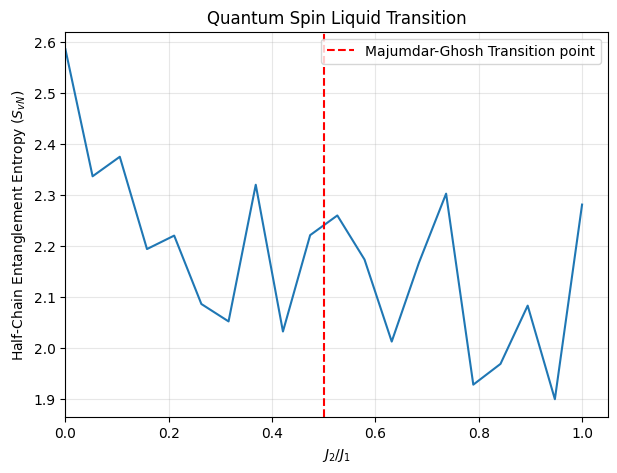

In [11]:
N = 14
N_up = N//2      # m^z = 0
J1 = 1.0         # Exchange coupling, nn
Delta1 = 1.0     # Anisotropy, nn
J2 = np.linspace(0,1.0,20) # Exchange coupling, nnn
Delta2 = 1.0     # Anisotropy, nnn

# Generating the Basis

basis,state_to_index = generate_basis(N,N_up)
dim = len(basis)

J2_J1 = J2/J1
entropy = []

for j2 in J2:
    H = build_hamiltonian_nnn(N,basis,state_to_index,J1,Delta1,j2,Delta2)

    # Exact Diagonalization (Lanczos)
    eigenenergies, eigenvectors = eigsh(H, k = 1, which = 'SA')
    psi_0 = eigenvectors[:,0]

    entropy.append(half_chain_entanglement_entropy(N, psi_0, basis))

plt.figure(figsize=(7, 5))
plt.plot(J2_J1, entropy)
plt.axvline(x = 0.5, color = 'r' ,linestyle = '--' , label = "Majumdar-Ghosh Transition point")
plt.legend()
plt.xlabel(r'$J_2 / J_1$')
plt.ylabel(r'Half-Chain Entanglement Entropy ($S_{vN}$)')
plt.title(r'Quantum Spin Liquid Transition')
plt.xlim(left=0)
plt.legend()
plt.grid(True, alpha=0.3)

### Analysis: Frustration and the Limits of U(1) Symmetry
The plot above scans the $J_1-J_2$ model to identify the Quantum Spin Liquid phase at the Majumdar-Ghosh point ($J_2/J_1 = 0.5$). However, the resulting entanglement entropy curve is highly noisy and jagged. This is not a bug in the Hamiltonian construction, but a direct physical consequence of geometric frustration and the limitations of utilizing only $U(1)$ magnetization symmetry.

**1. Ground State Degeneracy:**
At exactly $J_2/J_1 = 0.5$, the ground state becomes doubly degenerate (forming perfect dimer singlets). Because `scipy.sparse.linalg.eigsh` is not instructed on how to handle exact degeneracies, it returns an arbitrary linear combination of the two states, leading to unpredictable von Neumann entropy values.

**2. Level Crossings & Momentum Sectors:**
As $J_2$ increases, frustration causes the energy gap to collapse, and ground states from different momentum sectors (e.g., $k=0$ and $k=\pi$) cross one another. Because this solver currently implements only $U(1)$ symmetry ($S^z$ conservation) and lacks translational symmetry ($k$-sectoring), the Lanczos algorithm blindly jumps between entirely different macroscopic momentum states at each step of the loop.

**Conclusion:**
This numerical artifact demonstrates why advanced Exact Diagonalization solvers must implement $U(1) \times \mathbb{Z}_N$ (translational) symmetry. Projecting the Hamiltonian into specific momentum sectors would force the solver to track a single, continuous physical state across the phase boundary, resolving the level-crossing noise.